In [30]:
from tradepy.load import import_dataset, clean, wavelet_denoising, resample_ohlcv, daily_ohlcv_cummulative
from tradepy.analysis import plot_master_market_analysis
from tradepy.features import generate_features, data_quality_report
import json
import numpy as np

In [31]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


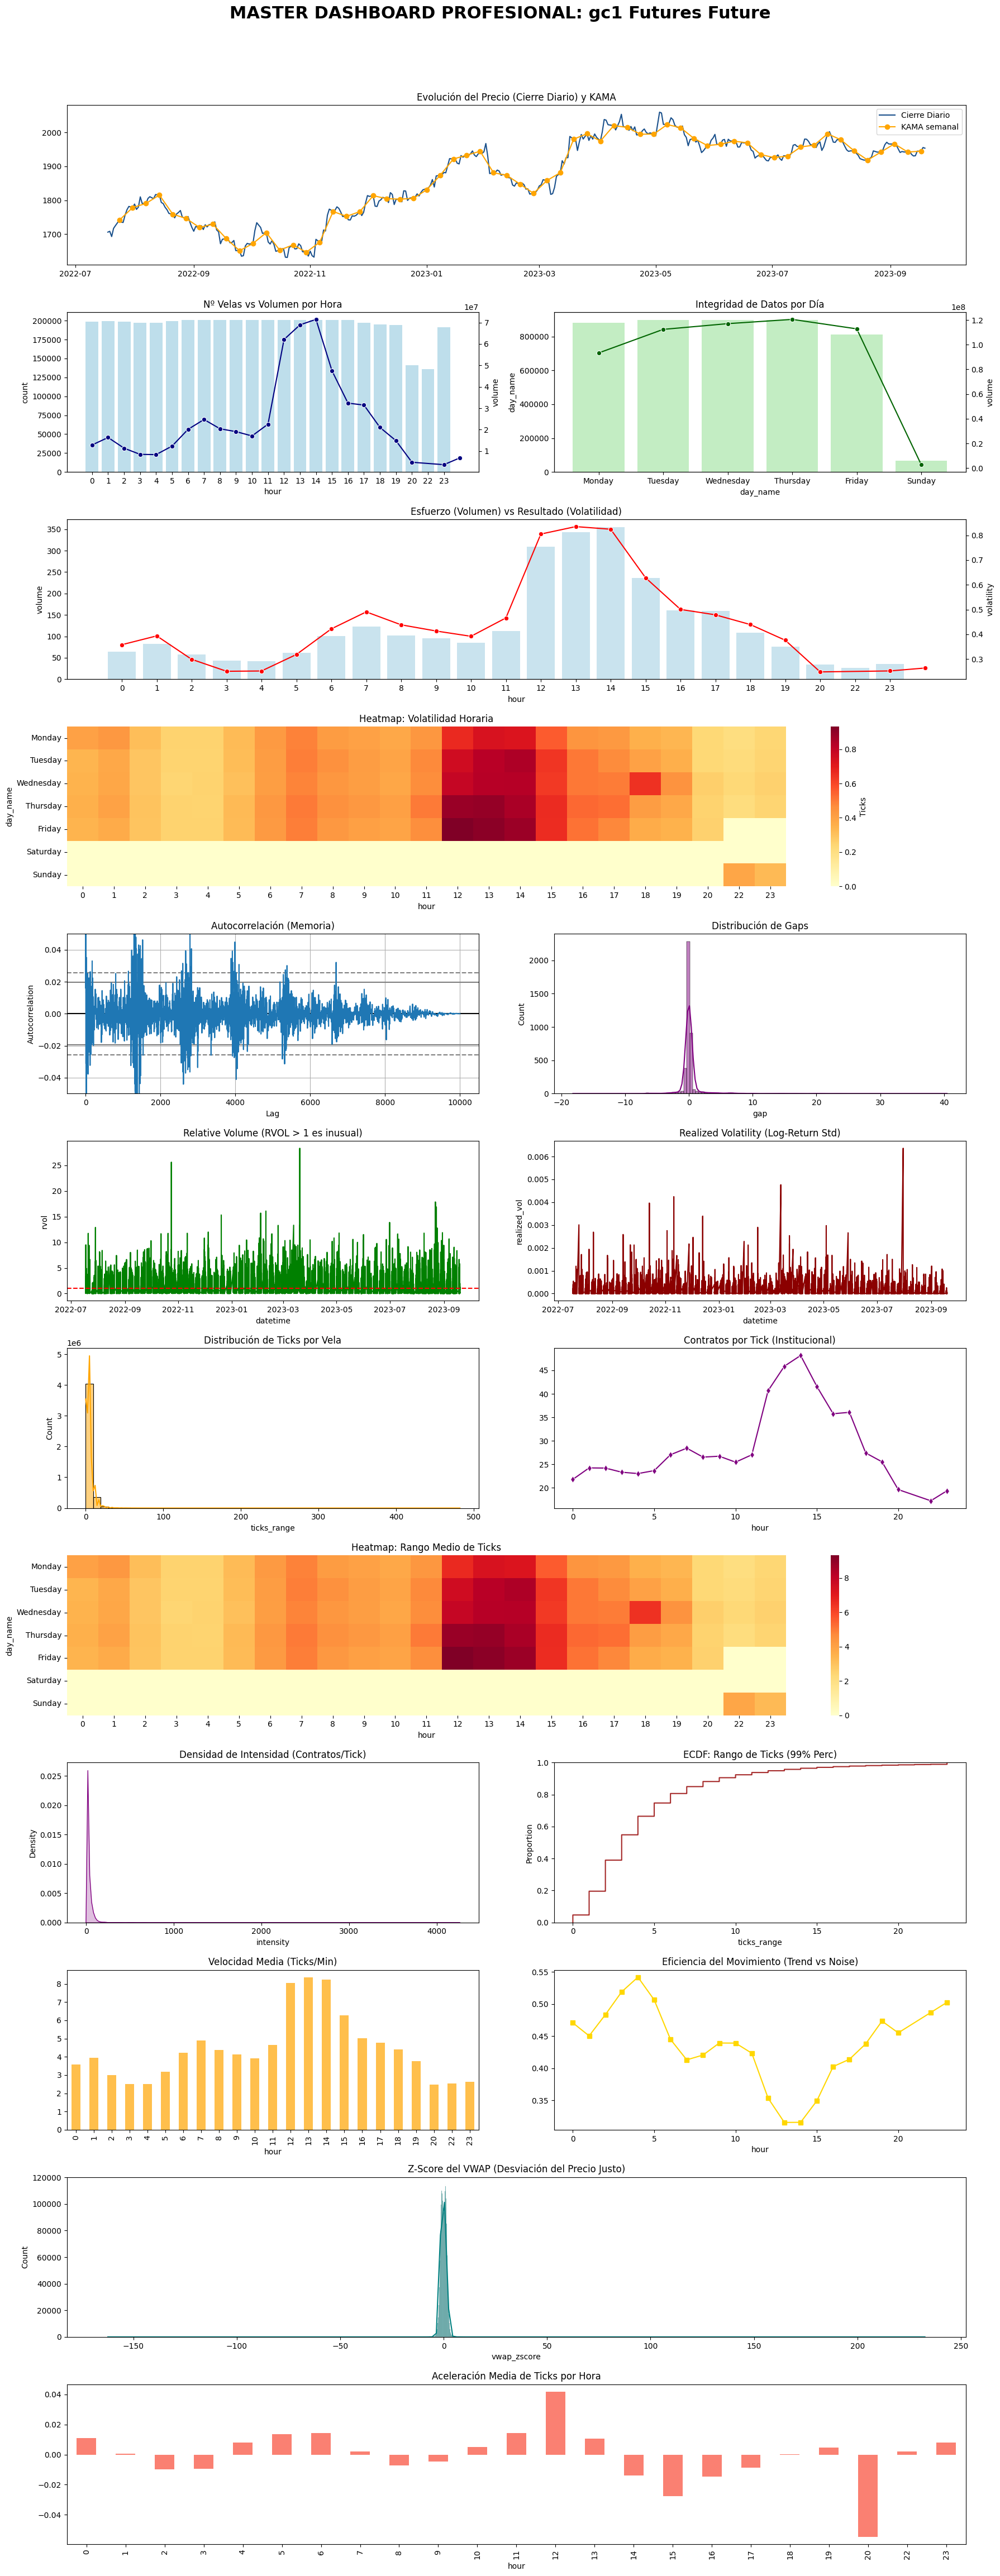

In [32]:
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, asset=ASSET)
df_min_clean["close"] = wavelet_denoising(df_min_clean['close'].values.copy())
df_resampled = resample_ohlcv(df_min_clean, period=f"{MINUTES}min")
df_cumulative = daily_ohlcv_cummulative(df_resampled)
plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

In [33]:
with open("features_config.json") as f:
    config = json.load(f)

config["global"]["sampling_minutes"] = MINUTES
config["global"]["return_horizon_min"] = RETURN_HORIZON_MIN
config["global"]["tick_size"] = spec["tick_size"]



In [34]:
df_final = generate_features(df_cumulative, config_json=config, dropna_strategy='any')

In [35]:
data_quality_report(df_final)

Data Quality Report
 - rows: 76740, cols: 151
 - top 20 NaN fractions:
datetime        0.0
open            0.0
high            0.0
low             0.0
close           0.0
volume          0.0
openint         0.0
dtyyyymmdd      0.0
ticker          0.0
per             0.0
trading_date    0.0
open_day        0.0
high_cum        0.0
low_cum         0.0
volume_cum      0.0
hour            0.0
minute          0.0
dayofweek       0.0
day             0.0
month           0.0
dtype: float64

Suggestions:
 - Drop or fix constant columns: ['openint', 'ticker', 'per', 'minute', 'minute_sin', 'minute_cos']
 - `rolling_slope` may be slow; consider vectorized replacement or numba.
 - To avoid fragmentation, build new columns in a dict and `pd.concat` once per group.


{'rows': 76740,
 'cols': 151,
 'na_fraction': {'datetime': 0.0,
  'open': 0.0,
  'high': 0.0,
  'low': 0.0,
  'close': 0.0,
  'volume': 0.0,
  'openint': 0.0,
  'dtyyyymmdd': 0.0,
  'ticker': 0.0,
  'per': 0.0,
  'trading_date': 0.0,
  'open_day': 0.0,
  'high_cum': 0.0,
  'low_cum': 0.0,
  'volume_cum': 0.0,
  'hour': 0.0,
  'minute': 0.0,
  'dayofweek': 0.0,
  'day': 0.0,
  'month': 0.0,
  'is_month_end': 0.0,
  'hour_sin': 0.0,
  'hour_cos': 0.0,
  'minute_sin': 0.0,
  'minute_cos': 0.0,
  'dow_sin': 0.0,
  'dow_cos': 0.0,
  'day_sin': 0.0,
  'day_cos': 0.0,
  'month_sin': 0.0,
  'month_cos': 0.0,
  'is_prev_break_hour': 0.0,
  'is_post_break_hour': 0.0,
  'is_NY_open_hour': 0.0,
  'week_of_month': 0.0,
  'seconds_since_midnight': 0.0,
  'session_progress': 0.0,
  'is_london': 0.0,
  'is_ny': 0.0,
  'is_overlap': 0.0,
  'sma_20': 0.0,
  'ema_20': 0.0,
  'dema': 0.0,
  'kama': 0.0,
  'ema_fast': 0.0,
  'ema_slow': 0.0,
  'macd': 0.0,
  'signal': 0.0,
  'histogram': 0.0,
  'rsi': 0.0,

In [36]:
df_final

,datetime,open,high,low,close,volume,openint,dtyyyymmdd,ticker,per,...,body_pct,upper_wick_pct,lower_wick_pct,close_location,dist_high_cum_ticks,dist_low_cum_ticks,dist_open_day_ticks,vol_per_tick,vol_vs_body,vol_weight_intraday
0,2010-09-22 07:00:00,1293.7,1294.3,1290.6,1291.383032,3483,0.0,2010-09-22,GC,60min,...,0.626207,0.162162,0.211630,0.211630,44.169676,24.830324,19.830324,91.657895,144.106193,0.231029
1,2010-09-22 08:00:00,1291.5,1292.1,1290.1,1291.713842,2372,0.0,2010-09-22,GC,60min,...,0.106921,0.193079,0.700000,0.806921,40.861583,28.138417,23.138417,112.952381,755.795040,0.135947
2,2010-09-22 09:00:00,1291.7,1296.5,1291.5,1294.029050,7597,0.0,2010-09-22,GC,60min,...,0.465810,0.494190,0.040000,0.505810,24.709499,51.290501,46.290501,148.960784,312.755999,0.303334
3,2010-09-22 10:00:00,1293.9,1295.5,1293.6,1294.513730,2855,0.0,2010-09-22,GC,60min,...,0.323016,0.519090,0.157895,0.480910,19.862704,56.137296,51.137296,142.750000,400.011449,0.102330
4,2010-09-22 11:00:00,1294.5,1295.0,1292.1,1294.465889,3284,0.0,2010-09-22,GC,60min,...,0.011763,0.172414,0.815824,0.815824,20.341114,55.658886,50.658886,109.466667,2448.710588,0.105310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76735,2023-09-19 00:00:00,1955.6,1956.0,1954.0,1954.097525,1555,0.0,2023-09-19,GC,60min,...,0.751237,0.200000,0.048763,0.048763,19.024748,102.975252,78.975252,74.047619,97.037407,0.014784
76736,2023-09-19 01:00:00,1954.3,1954.7,1953.2,1954.145181,2629,0.0,2023-09-19,GC,60min,...,0.103213,0.266667,0.630121,0.630121,5.548192,9.451808,-1.548192,164.312500,1031.711837,0.999620
76737,2023-09-19 02:00:00,1954.4,1954.7,1953.8,1954.042803,1265,0.0,2023-09-19,GC,60min,...,0.396886,0.333333,0.269781,0.269781,6.571973,8.428027,-2.571973,126.500000,276.685786,0.324775
76738,2023-09-19 03:00:00,1954.0,1954.4,1953.4,1953.588729,1128,0.0,2023-09-19,GC,60min,...,0.411271,0.400000,0.188729,0.188729,11.112706,3.887294,-7.112706,102.545455,220.626814,0.224567
